In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from flonacomldft.utils.plots import plotting_fes_db
from flonacomldft.utils.io_utils import (
    get_project_path,
    load_csv_file
)
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima, isomers
from flonacomldft.collective_variables import get_CVs
from flonacomldft.internal_coordinates import Coordinates_mapping
from ase.io.trajectory import Trajectory
from ase.io import read

In [3]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [4]:
coord_mapping = Coordinates_mapping()
mode_names = list(isomers.keys())

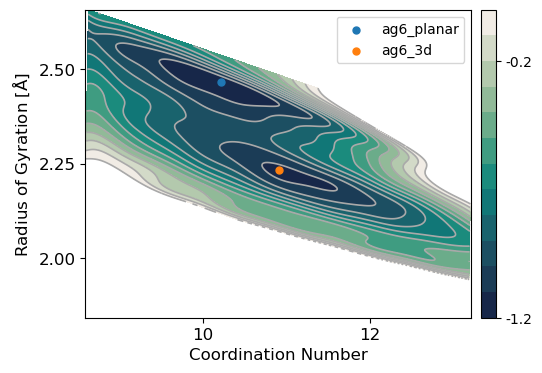

In [46]:
isomers_minima = [coord_mapping.get_internal_from_molecule(get_molecule_isomer_minima(mode_name))[0] for mode_name in mode_names]

cv_minima = np.array(get_CVs(isomers_minima)).T

fig, ax = plotting_fes_db()
for mode_name, cv in zip(mode_names, cv_minima):
    ax.scatter(*cv, marker='o', s=25, label=mode_name)
ax.legend()
fig.set_size_inches(6, 4)
size = 12
ax.xaxis.label.set_size(size)
ax.yaxis.label.set_size(size)
plt.xticks(fontsize=size)
plt.yticks(fontsize=size);

In [47]:
ids = np.arange(2206361, 2206365, 1)
path = get_project_path() + 'ag6_dft_calculations/structure_optimization/'
gpaw_modes = ['lcao', 'fd']

isomers_minima_recomputed = []
name_isomers = []

i = [0, 2, 1, 3]
j=0
for mode_name in mode_names:
    for gpaw_mode in gpaw_modes:
        name_isomer = '{:s}_{:s}'.format(mode_name, gpaw_mode)
        isomers_minima_recomputed.append(read(path + name_isomer + '_{:d}.out'.format(ids[i[j]])))
        name_isomers.append(name_isomer)
        j+=1

isomers_minima_recomputed = [coord_mapping.get_internal_from_molecule(isomer)[0] for isomer in isomers_minima_recomputed]

In [48]:
name_isomers

['ag6_planar_lcao', 'ag6_planar_fd', 'ag6_3d_lcao', 'ag6_3d_fd']

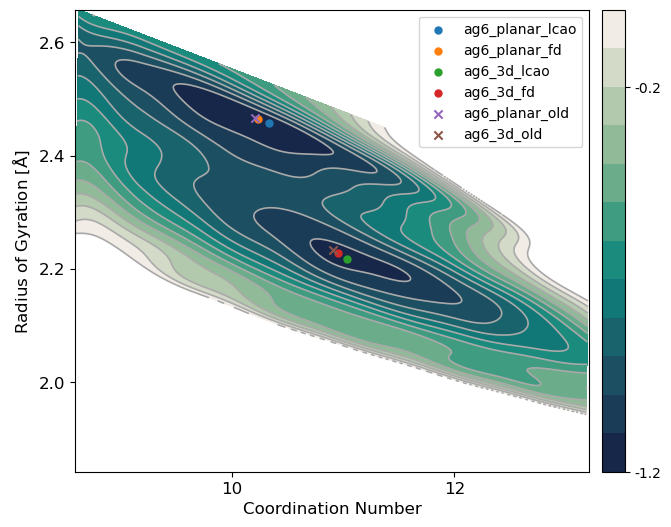

In [49]:
cv_minima_recomputed = np.array(get_CVs(isomers_minima_recomputed)).T

fig, ax = plotting_fes_db()
for name_isomer, cv in zip(name_isomers, cv_minima_recomputed):
    ax.scatter(*cv, marker='o', s=25, label=name_isomer)
for mode_name, cv in zip(mode_names, cv_minima):
    ax.scatter(*cv, marker='x', s=35, label=mode_name+'_old')
ax.legend()
fig.set_size_inches(8, 6)
size = 12
ax.xaxis.label.set_size(size)
ax.yaxis.label.set_size(size)
plt.xticks(fontsize=size)
plt.yticks(fontsize=size);

In [50]:
isomers_minima_recomputed = torch.stack(isomers_minima_recomputed)

Text(0.5, 0, 'internal coordinate')

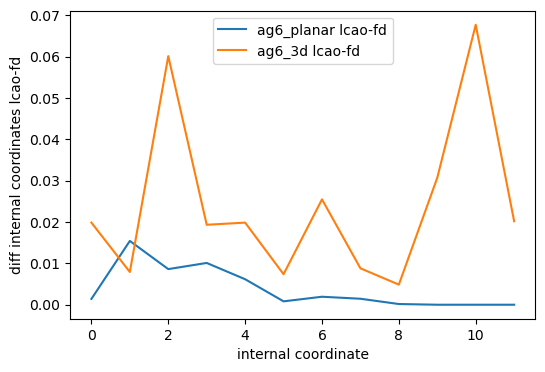

In [51]:
plt.figure(figsize = (6,4))
plt.plot(abs(isomers_minima_recomputed[0]-isomers_minima_recomputed[1]).detach().numpy(), label='ag6_planar lcao-fd')
plt.plot(abs(isomers_minima_recomputed[2]-isomers_minima_recomputed[3]).detach().numpy(), label='ag6_3d lcao-fd')
plt.legend()
plt.ylabel('diff internal coordinates lcao-fd')
plt.xlabel('internal coordinate')

In [52]:
# TODO: Plot distribution of internal coordinates for each isomer, md thermostat


In [6]:
mode_labels = [0, 1]

In [53]:
trajs_berendsen = [Trajectory(get_project_path() + '/database/md_trajectories/ag6_is{:d}_lcao.traj'.format(mode_label)) for mode_label in mode_labels]

temps = [[config.get_temperature() for config in traj] for traj in trajs_berendsen]

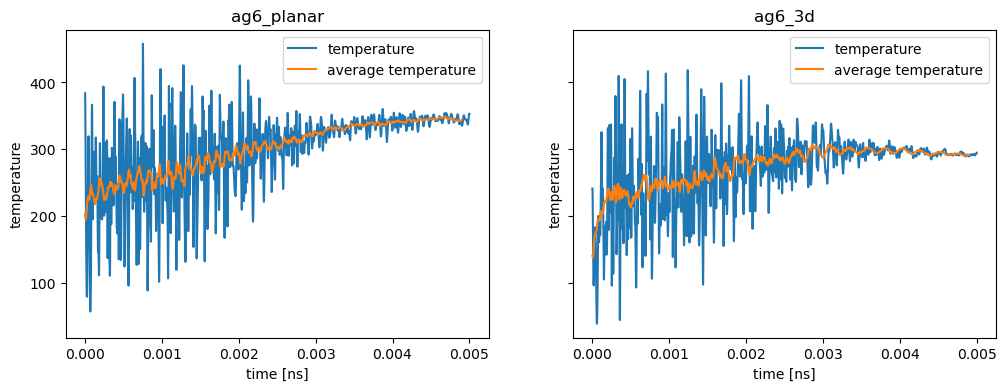

In [54]:
time = 1*np.arange(0, len(temps[0]))*1e-15*1e9

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for i in range(2):
    axs[i].plot(time, temps[i], label='temperature')
    axs[i].plot(time[:len(moving_average(temps[i], 100))], moving_average(temps[i], 100), label='average temperature')
    axs[i].legend()
    axs[i].set_title(mode_names[i])
    axs[i].set_ylabel('temperature')
    axs[i].set_xlabel('time [ns]') 

In [8]:
int_coords = [load_csv_file('database/int_coords/is{:d}_md_zmat.csv'.format(mode_label)) for mode_label in mode_labels]

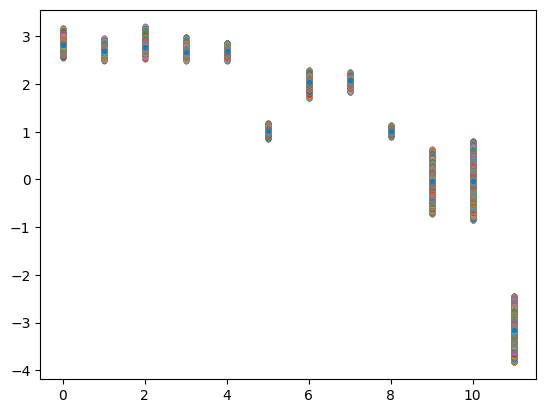

In [12]:
plt.plot(int_coords[0][:, :12].T.detach().numpy(), '.');

In [57]:
cvs = [get_CVs(int_coords[i][:, :12]) for i in range(2)]

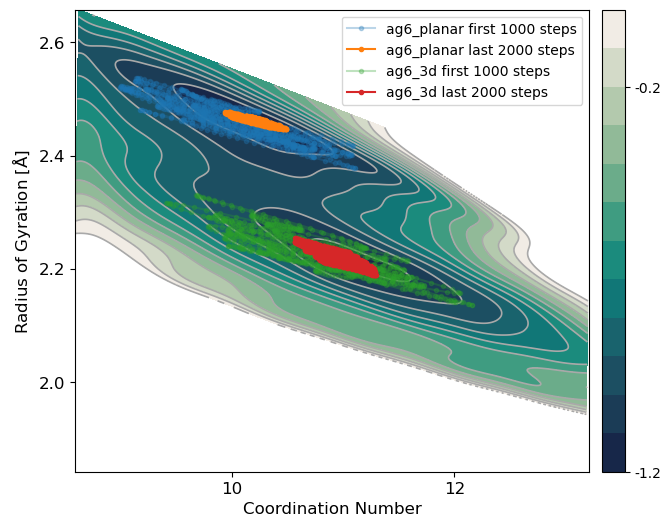

In [58]:
fig, ax = plotting_fes_db()
ax.plot(np.array(cvs[0]).T[:1000, 0], np.array(cvs[0]).T[:1000, 1], marker='.', alpha=0.3,label=mode_names[0]+' first 1000 steps');
ax.plot(np.array(cvs[0]).T[3000:, 0], np.array(cvs[0]).T[3000:, 1], marker='.', label=mode_names[0]+' last 2000 steps');
ax.plot(np.array(cvs[1]).T[:1000, 0], np.array(cvs[1]).T[:1000, 1], marker='.', alpha=0.3, label=mode_names[1]+' first 1000 steps');
ax.plot(np.array(cvs[1]).T[3000:, 0], np.array(cvs[1]).T[3000:, 1], marker='.', label=mode_names[1]+' last 2000 steps');
plt.legend()
fig.set_size_inches(8, 6)
size = 12
ax.xaxis.label.set_size(size)
ax.yaxis.label.set_size(size)
plt.xticks(fontsize=size)
plt.yticks(fontsize=size);

In [14]:
andersen_ids = [2206336, 2207841]

In [59]:
trajs_andersen = [Trajectory(get_project_path() + 'database_andersen/ag6_md_is{:d}_{:d}.traj'.format(mode_label, id)) for mode_label, id in zip(mode_labels, andersen_ids)]

In [60]:
temps_andersen = [[config.get_temperature() for config in traj] for traj in trajs_andersen]

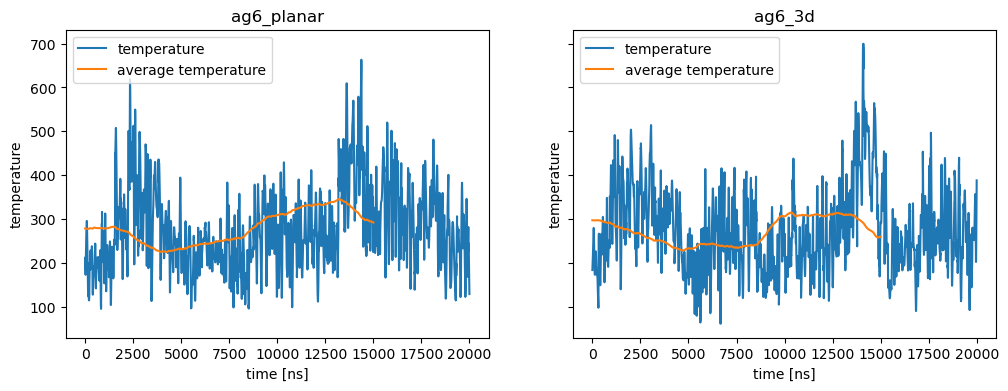

In [61]:
time_andersen = 1*np.arange(0, len(temps_andersen[0]))#*1e-15*1e9

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for i in range(2):
    axs[i].plot(time_andersen, temps_andersen[i], label='temperature')
    axs[i].plot(time_andersen[:len(moving_average(temps_andersen[i], 5000))], moving_average(temps_andersen[i], 5000), label='average temperature')
    axs[i].legend()
    axs[i].set_title(mode_names[i])
    axs[i].set_ylabel('temperature')
    axs[i].set_xlabel('time [ns]')

In [62]:
# Load andersen trajectories
# Train flows with the same data as for the berendsen trajectories
# Plot MH acceptance rate
# Plot FES

In [15]:
int_coords = [load_csv_file('database_andersen/is{:d}_md_zmat_{:d}.csv'.format(mode_label, id), get_project_path()) for mode_label, id in zip(mode_labels, andersen_ids)]

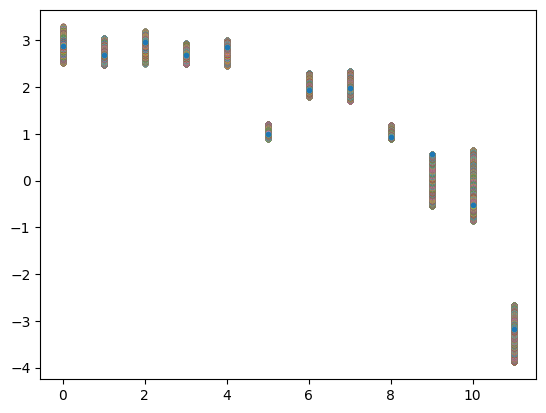

In [16]:
plt.plot(int_coords[0][:, :12].T.detach().numpy(), '.');

In [64]:
cvs = [get_CVs(int_coords[i][:, :12]) for i in range(2)]

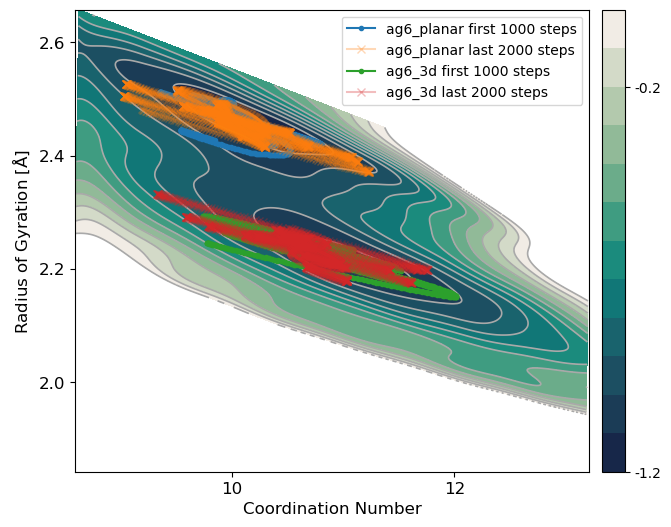

In [65]:
fig, ax = plotting_fes_db()
ax.plot(np.array(cvs[0]).T[:2000, 0], np.array(cvs[0]).T[:2000, 1], marker='.', label=mode_names[0]+' first 1000 steps');
ax.plot(np.array(cvs[0]).T[-2000:, 0], np.array(cvs[0]).T[-2000:, 1], marker='x', alpha=0.3, label=mode_names[0]+' last 2000 steps');
ax.plot(np.array(cvs[1]).T[:2000, 0], np.array(cvs[1]).T[:2000, 1], marker='.', label=mode_names[1]+' first 1000 steps');
ax.plot(np.array(cvs[1]).T[-2000:, 0], np.array(cvs[1]).T[-2000:, 1], marker='x', alpha=0.3, label=mode_names[1]+' last 2000 steps');
plt.legend()
fig.set_size_inches(8, 6)
size = 12
ax.xaxis.label.set_size(size)
ax.yaxis.label.set_size(size)
plt.xticks(fontsize=size)
plt.yticks(fontsize=size);

In [66]:
energy_berendsen = [[config.get_potential_energy() for config in traj] for traj in trajs_berendsen]
energy_andersen = [[config.get_potential_energy() for config in traj] for traj in trajs_andersen]

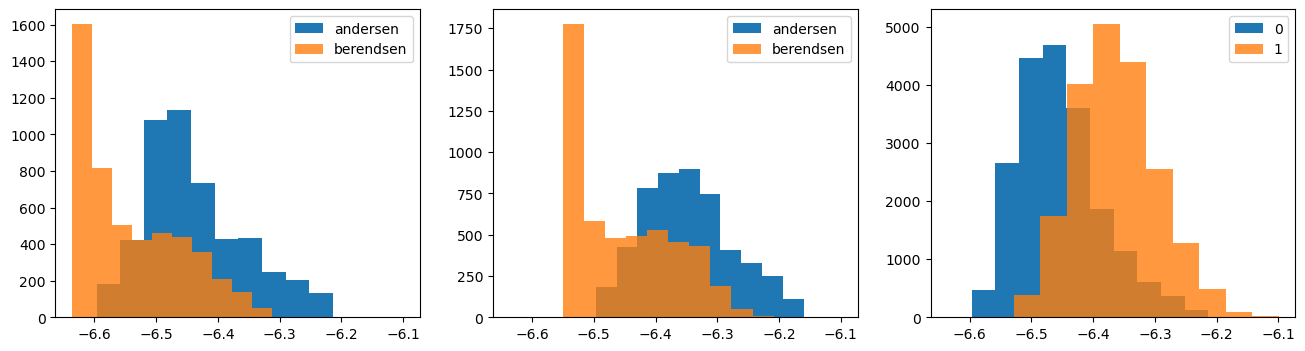

In [67]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
for i in range(2):
    axs[i].hist(energy_andersen[i][:len(energy_berendsen[i])], label='andersen')
    axs[i].hist(energy_berendsen[i], alpha=0.8, label='berendsen')
    axs[i].legend()

axs[2].hist(energy_andersen[0], label=0)
axs[2].hist(energy_andersen[1], alpha=0.8, label=1)
axs[2].legend()

In [1]:
import torch
import  numpy as np
from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
import matplotlib.pyplot as plt
from flonacomldft.internal_coordinates import Coordinates_mapping

In [2]:
mode_labels = [0, 1]
andersen_ids = [22249210, 22249211]
andersen_ids = [22249330, 22249331]
mlps = [load_pickle_file('database/andersen/is{:d}_mlp_dic_training_{:d}.pkl'.format(mode_label, id)) for mode_label, id in zip(mode_labels, andersen_ids)]

In [27]:
zmats_train = [load_csv_file("database/andersen/is{:d}_md_train.csv".format(mode_label)) for mode_label in [0, 1]]
zmats_test = [load_csv_file("database/andersen/is{:d}_md_test.csv".format(mode_label)) for mode_label in [0, 1]]

In [28]:
coord_mapping = Coordinates_mapping()

xs_train = []
xs_train_logdetjacs = []
us_train = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_train[mode_label][:, :12], logdetjacs=zmats_train[mode_label][:, 14], energies=zmats_train[mode_label][:, 12], isomer=mode_label)
    xs_train.append(xs)
    xs_train_logdetjacs.append(logdetjacs)
    us_train.append(us)

xs_test = []
xs_test_logdetjacs = []
us_test = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_test[mode_label][:, :12], logdetjacs=zmats_test[mode_label][:, 14], energies=zmats_test[mode_label][:, 12], isomer=mode_label)
    xs_test.append(xs)
    xs_test_logdetjacs.append(logdetjacs)
    us_test.append(us)

u_target_train = torch.stack(us_train).detach().numpy()
u_predict_train = [mlps[mode_label]['model'](xs_train[mode_label]).T.detach().numpy() for mode_label in [0, 1]]

u_target_test = torch.stack(us_test).detach().numpy()
u_predict_test = [mlps[mode_label]['model'](xs_test[mode_label]).T.detach().numpy() for mode_label in [0, 1]]

u_target = {'train': u_target_train, 'test': u_target_test}
u_predict = {'train': u_predict_train, 'test': u_predict_test}

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an ind

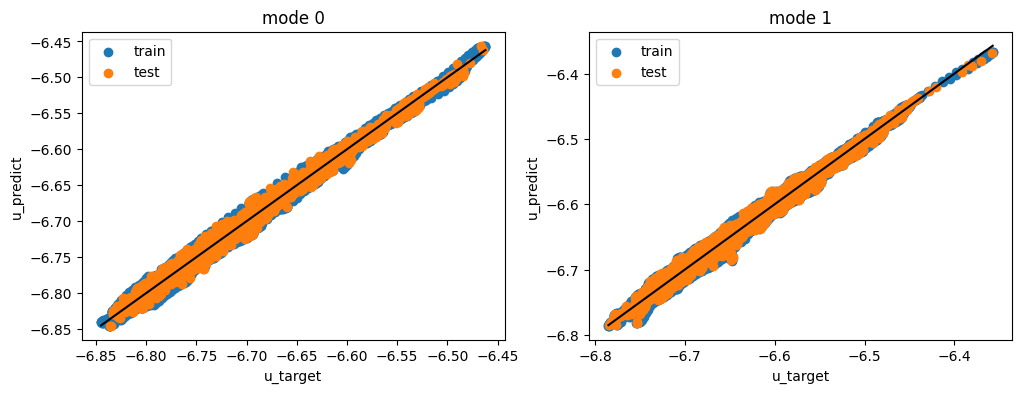

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for mode_label in [0, 1]:
    axs[mode_label].scatter(u_target['train'][mode_label].flatten(), u_predict['train'][mode_label].flatten(), label='train')
    axs[mode_label].scatter(u_target['test'][mode_label].flatten(), u_predict['test'][mode_label].flatten(), label='test')
    min_ = np.min(u_target['train'][mode_label].flatten())
    max_ = np.max(u_target['train'][mode_label].flatten())
    range_ = np.linspace(min_, max_, 2)
    axs[mode_label].plot(range_, range_, color='k')
    axs[mode_label].set_ylabel('u_predict')
    axs[mode_label].set_xlabel('u_target')
    axs[mode_label].legend()
    axs[mode_label].set_title('mode {:d}'.format(mode_label))

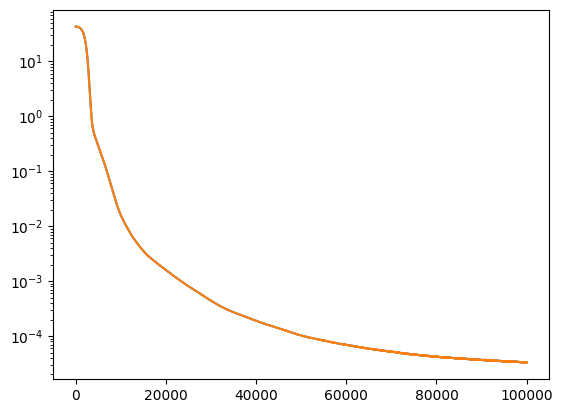

In [30]:
plt.plot(mlps[0]['losses'][0], label='train')
plt.plot(mlps[0]['losses'][0], label='test')
plt.yscale('log')

In [3]:
import torch
import  numpy as np
from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
import matplotlib.pyplot as plt
from flonacomldft.internal_coordinates import Coordinates_mapping

In [4]:
mlps_names = ['is0_mlp_dic_training_22256890.pkl', 'is0_mlp_dic_training_22256892.pkl', 'is1_mlp_dic_training_22256891.pkl', 'is1_mlp_dic_training_22256893.pkl']

In [5]:
mlps = [load_pickle_file('database/andersen/' + mlp_name) for mlp_name in mlps_names]

In [24]:
zmats_train = [load_csv_file("database/andersen/is{:d}_md_train.csv".format(mode_label)) for mode_label in [0, 1]]
zmats_test = [load_csv_file("database/andersen/is{:d}_md_test.csv".format(mode_label)) for mode_label in [0, 1]]

coord_mapping = Coordinates_mapping()

xs_train = []
xs_train_logdetjacs = []
us_train = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_train[mode_label][:, :12], logdetjacs=zmats_train[mode_label][:, 14], energies=zmats_train[mode_label][:, 12], isomer=mode_label)
    xs_train.append(xs)
    xs_train_logdetjacs.append(logdetjacs)
    us_train.append(us)

xs_test = []
xs_test_logdetjacs = []
us_test = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_test[mode_label][:, :12], logdetjacs=zmats_test[mode_label][:, 14], energies=zmats_test[mode_label][:, 12], isomer=mode_label)
    xs_test.append(xs)
    xs_test_logdetjacs.append(logdetjacs)
    us_test.append(us)

u_target_train = torch.stack(us_train).detach().numpy()
u_predict_train = []


for mode_label in [0]:
    for mlp in mlps[:2]:
        u_predict_train.append(mlp['model'](xs_train[mode_label]).T.detach().numpy())

for mode_label in [1]:
    for mlp in mlps[2:]:
        u_predict_train.append(mlp['model'](xs_train[mode_label]).T.detach().numpy())

u_target_test = torch.stack(us_test).detach().numpy()
u_predict_test = []

for mode_label in [0]:
    for mlp in mlps[:2]:
        u_predict_test.append(mlp['model'](xs_test[mode_label]).T.detach().numpy())

for mode_label in [1]:
    for mlp in mlps[2:]:
        u_predict_test.append(mlp['model'](xs_test[mode_label]).T.detach().numpy())


u_target = {'train': u_target_train, 'test': u_target_test}
u_predict = {'train': u_predict_train, 'test': u_predict_test}

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an ind

In [25]:
u_predict['train'], u_predict['test']

([array([[-6.6878586, -6.7675743, -6.6994967, ..., -6.7849293, -6.7212696,
          -6.806521 ]], dtype=float32),
  array([[-6.686508 , -6.767551 , -6.6923733, ..., -6.7693853, -6.7297945,
          -6.7995424]], dtype=float32),
  array([[-6.676281 , -6.6901627, -6.6519575, ..., -6.679232 , -6.6500897,
          -6.6849613]], dtype=float32),
  array([[-6.671421 , -6.694759 , -6.6362853, ..., -6.6755276, -6.6363864,
          -6.7011294]], dtype=float32)],
 [array([[-6.7124815, -6.618688 , -6.688883 , ..., -6.691157 , -6.782959 ,
          -6.5602674]], dtype=float32),
  array([[-6.7176456, -6.622156 , -6.6865544, ..., -6.7046404, -6.769621 ,
          -6.559079 ]], dtype=float32),
  array([[-6.6119647, -6.5815816, -6.579538 , ..., -6.656951 , -6.678352 ,
          -6.581284 ]], dtype=float32),
  array([[-6.6114306, -6.574033 , -6.573391 , ..., -6.6461835, -6.6761584,
          -6.578172 ]], dtype=float32)])

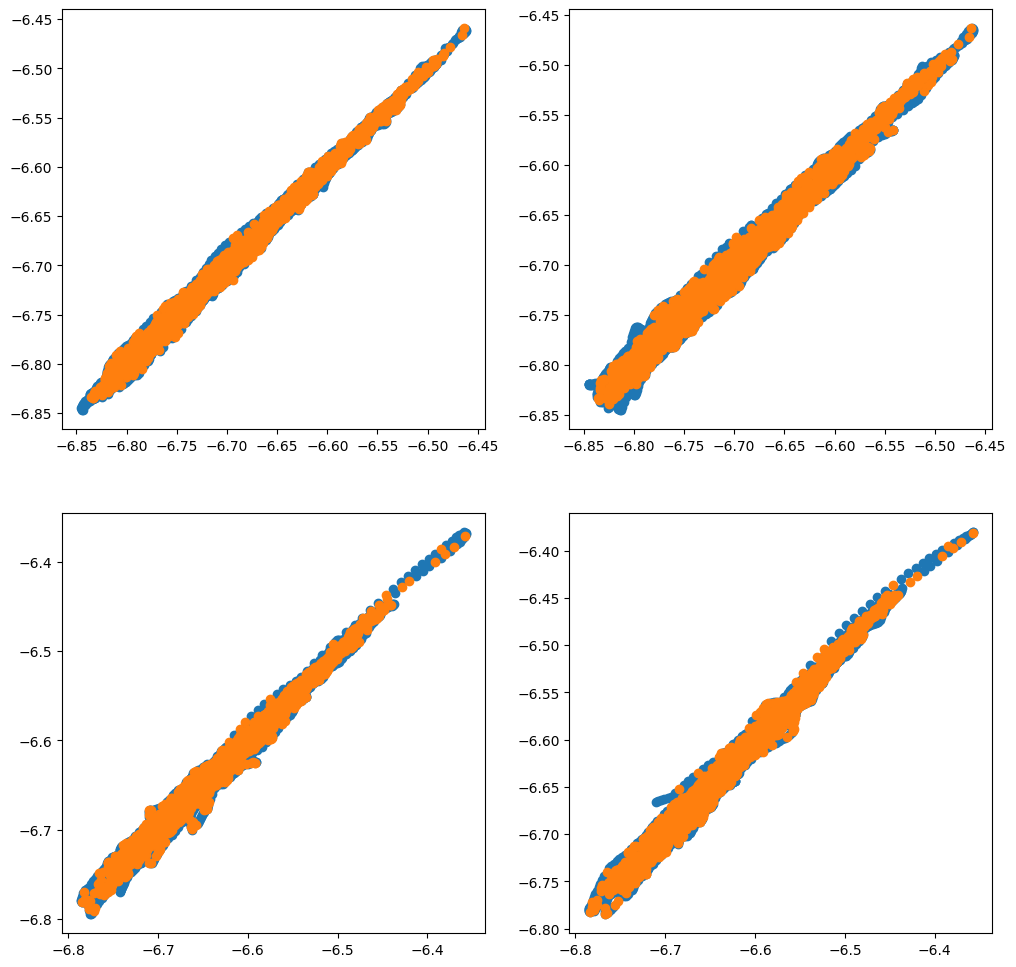

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs[0][0].scatter(u_target['train'][0].flatten(), u_predict['train'][0].flatten(), label='train')
axs[0][0].scatter(u_target['test'][0].flatten(), u_predict['test'][0].flatten(), label='test')

axs[0][1].scatter(u_target['train'][0].flatten(), u_predict['train'][1].flatten(), label='train')
axs[0][1].scatter(u_target['test'][0].flatten(), u_predict['test'][1].flatten(), label='test')

axs[1][0].scatter(u_target['train'][1].flatten(), u_predict['train'][2].flatten(), label='train')
axs[1][0].scatter(u_target['test'][1].flatten(), u_predict['test'][2].flatten(), label='test')

axs[1][1].scatter(u_target['train'][1].flatten(), u_predict['train'][3].flatten(), label='train')
axs[1][1].scatter(u_target['test'][1].flatten(), u_predict['test'][3].flatten(), label='test')

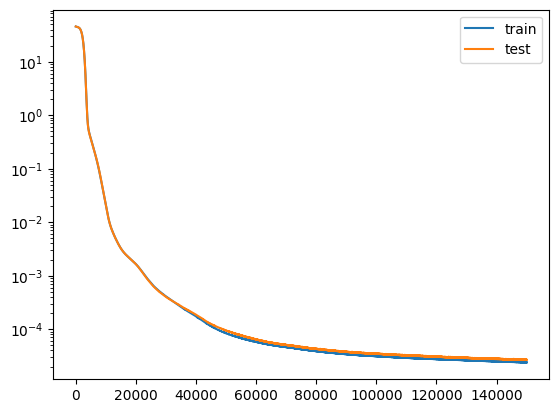

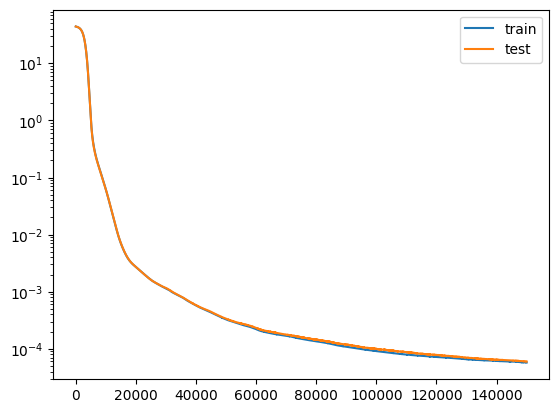

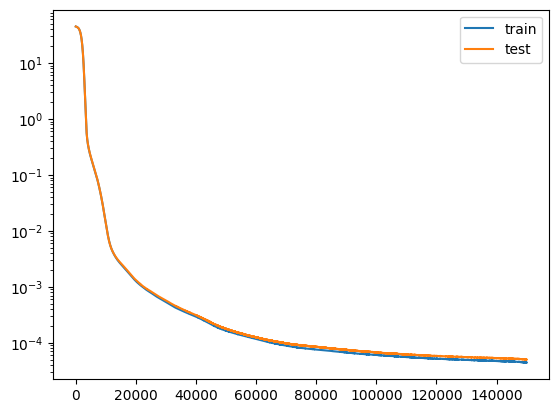

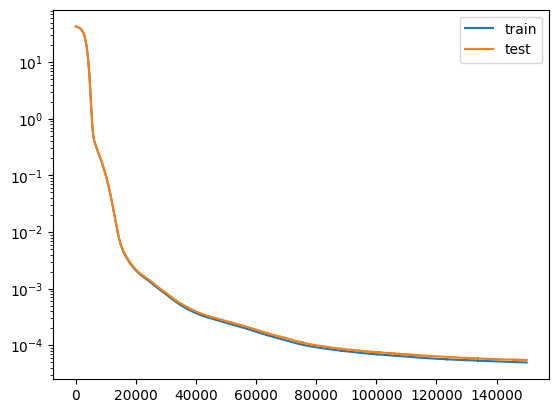

In [32]:
for i in range(4):
    plt.figure()
    plt.plot(mlps[i]['losses'][0])
    plt.plot(mlps[i]['losses'][1])
    plt.legend(['train', 'test'])
    plt.yscale('log')